## Tarea Clasificación
### Materia: Laboratorio de Aprendizaje Estádistico 
### Profesor: Antonio Manguart Paez
### Alumna: Maria Fernanda Gómez Flores


Convertir el precio de las casas a clasificación

1 = casas con precio mayor a 250000  
0 = casas con precio menor o igual a 250000

Crear:
- KNN
- Regresión logística
- Polinomial
- Ridge
- LDA

Obtener el modelo con mayor AUC

Realizar calibración


## Preparación de datos


In [3]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model


In [4]:
df = pd.read_csv('../Data/housing.csv')
df.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [5]:
df.isna().mean()


longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        0.010029
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

In [6]:
df = df.fillna(df.mean(numeric_only=True))


In [7]:
df.isna().mean()


longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        0.0
population            0.0
households            0.0
median_income         0.0
median_house_value    0.0
ocean_proximity       0.0
dtype: float64

## Target


In [8]:
df['target'] = df['median_house_value'] > 250000


In [9]:
df.target.mean()


np.float64(0.2801356589147287)

El target es 1 cuando la casa vale mas de 250000 y 0 cuando vale 250000 o menos


In [10]:
y = df['target']

X = df.copy()
del X['median_house_value']
del X['target']


ocean_proximity es categorica entonces la convierto a dummies


In [11]:
categoricas = [
    'ocean_proximity'
]


In [12]:
X = pd.get_dummies(X, columns=categoricas)


In [13]:
X.head()


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,False,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,False,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,False,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,False,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,False,False,False,True,False


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0)


## Regresión Logística


In [15]:
from sklearn.linear_model import LogisticRegression


In [16]:
model_logistica = LogisticRegression(max_iter=2000)
model_logistica.fit(X_train,y_train)


LogisticRegression(max_iter=2000)

In [17]:
probabilidades_logistica = model_logistica.predict_proba(X_test)[:,1]
probabilidades_logistica


array([0.15423023, 0.70895325, 0.08088323, ..., 0.96917455, 0.00632459,
       0.47417225])

In [18]:
from sklearn.metrics import roc_auc_score

auc_logistica = roc_auc_score(y_score=probabilidades_logistica, y_true=y_test)
auc_logistica


np.float64(0.9149319881716765)

In [19]:
from sklearn.metrics import roc_curve

fpr_logistica, tpr_logistica, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_logistica
)


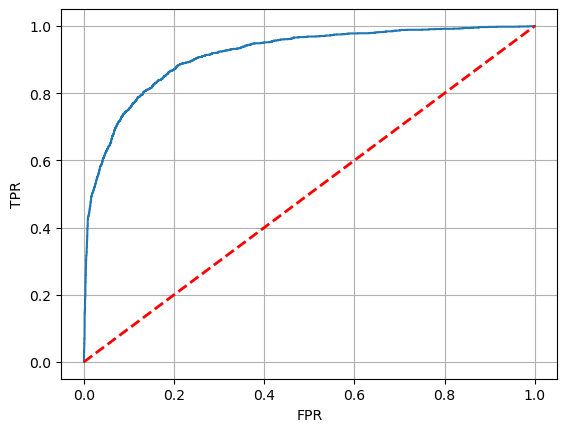

In [20]:
plt.plot(fpr_logistica,tpr_logistica)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()


El AUC de la regresión logística es aproximadamente 0.915 por lo que logra separar bastante bien las dos clases


## KNN


In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


In [22]:
model_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

model_knn.fit(X_train,y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier())])

In [23]:
probabilidades_knn = model_knn.predict_proba(X_test)[:,1]
probabilidades_knn


array([0. , 0.4, 0. , ..., 1. , 0. , 0.4])

In [24]:
auc_knn = roc_auc_score(y_score=probabilidades_knn, y_true=y_test)
auc_knn


np.float64(0.9038448370110825)

In [25]:
fpr_knn, tpr_knn, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_knn
)


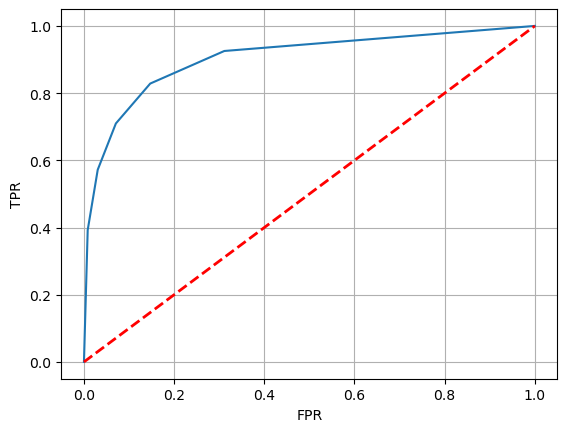

In [26]:
plt.plot(fpr_knn,tpr_knn)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()


El KNN usa los vecinos mas cercanos para clasificar. Se escalaron las variables porque trabaja con distancias


## Polinomial


In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


In [28]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('scaler', StandardScaler()),
    ('model', linear_model.LogisticRegression())
])


In [29]:
params = {
    'poly__degree': [2]
}


In [30]:
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=params,
    scoring='roc_auc',
    cv=5
)


In [31]:
grid.fit(X_train,y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('scaler', StandardScaler()),
                                       ('model', LogisticRegression())]),
             param_grid={'poly__degree': [2]}, scoring='roc_auc')

In [32]:
grid.best_params_


{'poly__degree': 2}

In [33]:
probabilidades_poly = grid.predict_proba(X_test)[:,1]
probabilidades_poly


array([0.0816953 , 0.54733906, 0.02734421, ..., 0.97529191, 0.01117437,
       0.44879476])

In [34]:
auc_poly = roc_auc_score(y_score=probabilidades_poly, y_true=y_test)
auc_poly


np.float64(0.9374422198313855)

In [35]:
fpr_poly, tpr_poly, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_poly
)


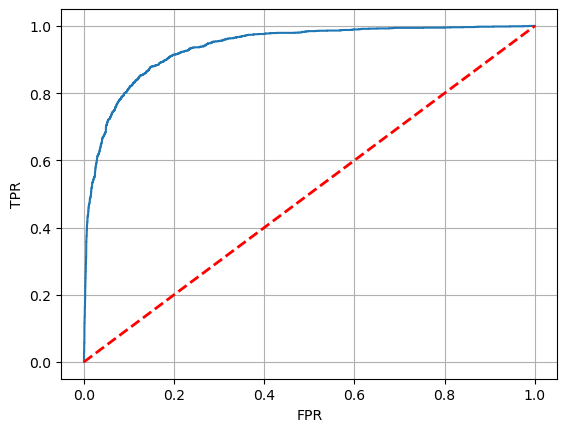

In [36]:
plt.plot(fpr_poly,tpr_poly)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()


El modelo polinomial agrega relaciones de grado 2 entre las variables para ver si mejora la clasificación


## Ridge


In [37]:
model_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', linear_model.LogisticRegression(penalty='l2'))
])

model_ridge.fit(X_train,y_train)


Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression())])

In [38]:
probabilidades_ridge = model_ridge.predict_proba(X_test)[:,1]
probabilidades_ridge


array([0.12148247, 0.60864022, 0.05973048, ..., 0.94992027, 0.00401954,
       0.5955251 ])

In [39]:
auc_ridge = roc_auc_score(y_score=probabilidades_ridge, y_true=y_test)
auc_ridge


np.float64(0.9262983926845036)

In [40]:
fpr_ridge, tpr_ridge, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_ridge
)


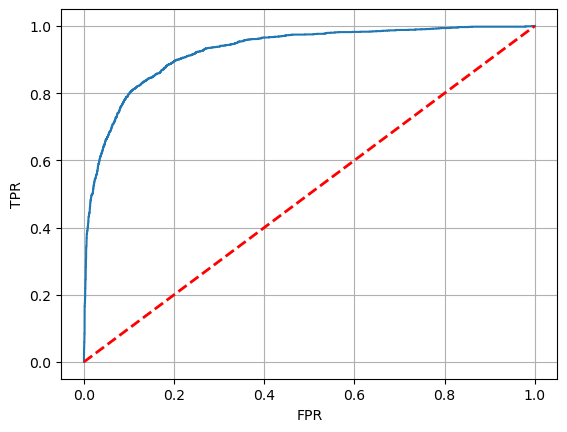

In [41]:
plt.plot(fpr_ridge,tpr_ridge)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()


Ridge usa penalización L2 para controlar los coeficientes del modelo


## LDA


In [42]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [43]:
model_lda = LinearDiscriminantAnalysis()
model_lda.fit(X_train,y_train)


LinearDiscriminantAnalysis()

In [44]:
probabilidades_lda = model_lda.predict_proba(X_test)[:,1]
probabilidades_lda


array([0.16144958, 0.54602473, 0.12742167, ..., 0.91312237, 0.0095372 ,
       0.51358056])

In [45]:
auc_lda = roc_auc_score(y_score=probabilidades_lda, y_true=y_test)
auc_lda


np.float64(0.9201626852269884)

In [46]:
fpr_lda, tpr_lda, umbrales = roc_curve(
    y_true=y_test,
    y_score=probabilidades_lda
)


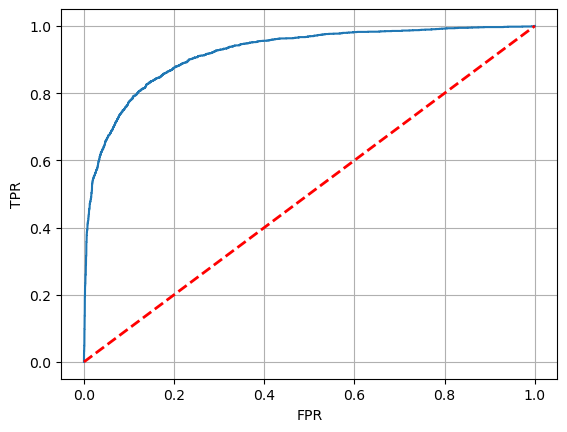

In [47]:
plt.plot(fpr_lda,tpr_lda)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.grid()


LDA busca una combinación de las variables que permita separar las dos clases


## Comparación de modelos


In [48]:
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística','KNN','Polinomial','Ridge','LDA'],
    'AUC': [auc_logistica,auc_knn,auc_poly,auc_ridge,auc_lda]
})

resultados = resultados.sort_values(by='AUC',ascending=False)
resultados


,Modelo,AUC
2,Polinomial,0.937442
3,Ridge,0.926298
4,LDA,0.920163
0,Regresión Logística,0.914932
1,KNN,0.903845


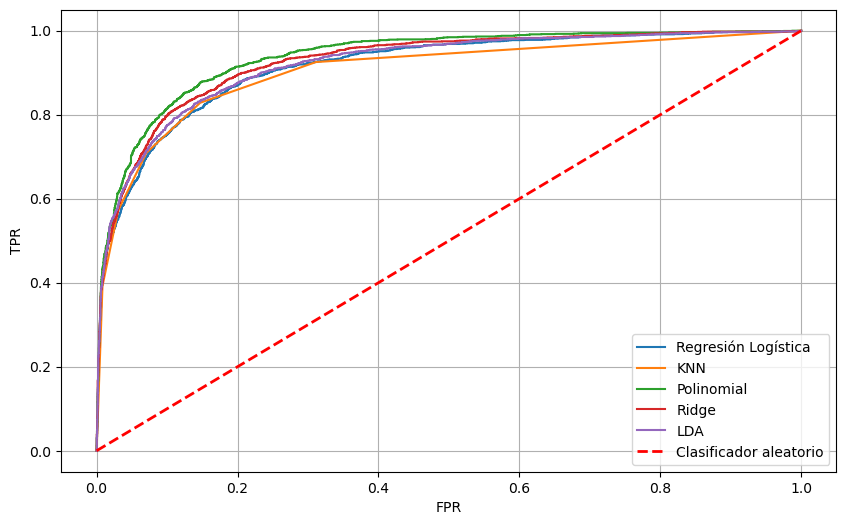

In [49]:
plt.figure(figsize=(10,6))

plt.plot(fpr_logistica,tpr_logistica,label="Regresión Logística")
plt.plot(fpr_knn,tpr_knn,label="KNN")
plt.plot(fpr_poly,tpr_poly,label="Polinomial")
plt.plot(fpr_ridge,tpr_ridge,label="Ridge")
plt.plot(fpr_lda,tpr_lda,label="LDA")

plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Clasificador aleatorio')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid()


El mejor modelo fue el polinomial con un AUC de aproximadamente 0.9374 por lo que fue el que mejor logro separar las casas que cuestan mas de 250000 de las que cuestan 250000 o menos


## Calibración


In [50]:
df_calibracion = pd.DataFrame({
    'y': y_test,
    'probabilidad': probabilidades_poly
})


In [51]:
df_calibracion['probabilidad_bin'] = pd.qcut(
    df_calibracion['probabilidad'],
    q=10,
    labels=False
) + 1


In [52]:
calibracion = df_calibracion.groupby('probabilidad_bin').mean()
calibracion


,y,probabilidad
probabilidad_bin,,
1,0.009677,0.001404
2,0.006462,0.007014
3,0.017771,0.018545
4,0.024233,0.040374
5,0.050081,0.079434
6,0.132472,0.153429
7,0.284330,0.283056
8,0.531502,0.498798
9,0.794830,0.775320


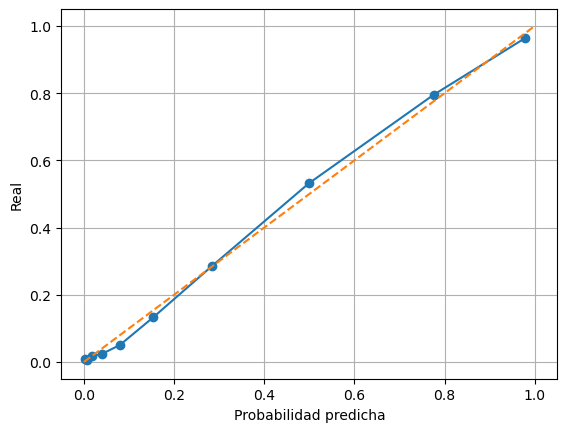

In [53]:
plt.plot(calibracion.probabilidad, calibracion.y, marker="o")
plt.plot([0,1],[0,1],"--")
plt.xlabel("Probabilidad predicha")
plt.ylabel("Real")
plt.grid()


La calibración compara la probabilidad que predice el modelo contra lo que realmente paso

Si los puntos estan cerca de la diagonal significa que las probabilidades del modelo estan bien calibradas


## Conclusión


Se compararon los 5 modelos usando AUC porque permite medir que tan bien separan las dos clases

El polinomial fue el que obtuvo el AUC mas alto con aproximadamente 0.9374 por lo que fue el mejor modelo de los que se probaron

Despues se reviso su calibración comparando las probabilidades predichas contra la proporción real de casas mayores a 250000
